Contexto do Problema

Você atua como Analista de Dados em uma empresa de software (SaaS) e recebeu uma base de dados contendo o registro de interação dos usuários com o sistema. O objetivo é compreender o perfil de engajamento, identificar padrões de uso entre diferentes planos de assinatura e visualizar a correlação entre problemas reportados e a satisfação do cliente. Como os dados possuem múltiplas variáveis categóricas e numéricas, você utilizará a biblioteca seaborn para criar visualizações estatísticas diretas e elegantes.

1. Configuração do Ambiente e Base de Dados

Execute o bloco abaixo no Google Colab ou Jupyter para importar as bibliotecas e gerar o DataFrame sintético da atividade:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

2. Roteiro de Tarefas

Parte 1: Distribuições e Contagens (Básico)

Crie um gráfico de barras para exibir a contagem de usuários por tipo de plano. Utilize a função countplot e ordene as barras pela frequência.

/tmp/ipykernel_1854/1567880188.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sistema, x='plano', order=plan_order, palette='viridis')


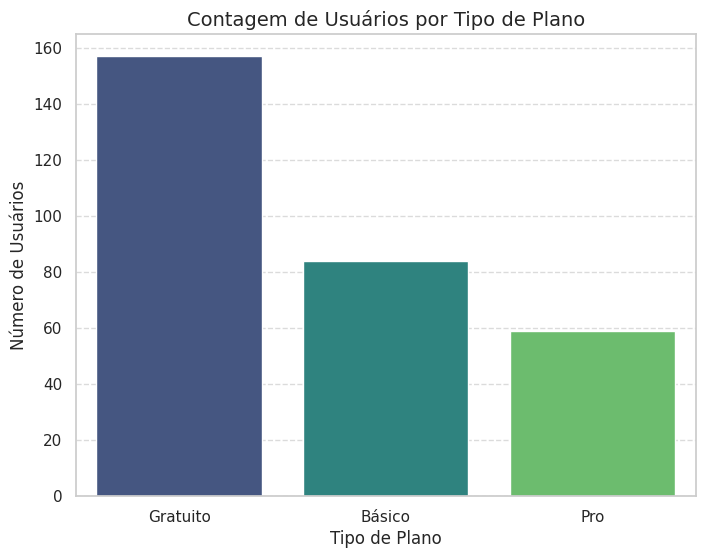

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordem dos planos por frequência
plan_order = df_sistema['plano'].value_counts().index

plt.figure(figsize=(8, 6))
sns.countplot(data=df_sistema, x='plano', order=plan_order, hue='plano', palette='viridis', legend=False)
plt.title('Contagem de Usuários por Tipo de Plano', fontsize=14)
plt.xlabel('Tipo de Plano', fontsize=12)
plt.ylabel('Número de Usuários', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Analise a distribuição da variável idade utilizando um histplot. Adicione a curva de densidade (KDE) para suavizar a visualização.

Parte 2: Relações Categóricas e Numéricas (Intermediário)

 3. Construa um boxplot para comparar a distribuição do tempo_uso_horas entre os diferentes tipos de plano.

4. Crie um violinplot cruzando o plano com a satisfacao. Esse gráfico ajudará a entender não apenas a mediana, mas a densidade das notas dadas pelos clientes de cada plano.


Parte 3: Correlações e Análise Multivariada (Avançado)

 5. Utilize um scatterplot para investigar a relação entre tempo_uso_horas (eixo X) e satisfacao (eixo Y). Utilize o parâmetro hue para colorir os pontos de acordo com o plano e size para variar o tamanho dos pontos com base nos bugs_reportados.

 6. Calcule a matriz de correlação de Pearson apenas para as variáveis numéricas do DataFrame e visualize-a utilizando um heatmap. Configure a paleta de cores para divergir do centro (ex: 'coolwarm' ou 'vlag') e ative as anotações numéricas (annot=True).

7. (Bônus) Gere um pairplot englobando as variáveis tempo_uso_horas, bugs_reportados e satisfacao, utilizando o plano como hue.
